In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#for fill the missing value with mean of the columns data
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [4]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
df.drop(columns=['area_type', 'availability', 'location', 'size', 'society', 'bath', 'balcony'],inplace=True)

In [6]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [7]:
def convertRange(x):
    try:
        temp = str(x).split('-')
        if len(temp) == 2:
            return (float(temp[0]) + float(temp[1]))/2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convertRange)

In [8]:
# df.isnull().sum()

In [9]:
df.isnull().sum()

total_sqft    46
price          0
dtype: int64

In [18]:
X = df[['total_sqft']]
y = df['price']
df.dropna(inplace=True)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

In [20]:
# # imputer = SimpleImputer(strategy='mean')  
# # X_filled = imputer.fit_transform(X)

# df['total_sqft'] = df['total_sqft'].fillna(df['total_sqft'].mean())

# df = df.fillna(df.mean(numeric_only=True))


X = df[['total_sqft']]


In [21]:
# print(X.isnull().sum())
X.isna().sum()

total_sqft    0
dtype: int64

In [22]:
#training the model 
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [16]:
df['total_sqft'].isna().sum()

0

In [24]:
#predicting 
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error {mse}")
print(f"Model coefficient {model.coef_}")
print(f"Model intercept {model.intercept_}")

Mean Squared Error 18267.968569927314
Model coefficient [0.06111686]
Model intercept 16.03897899604523


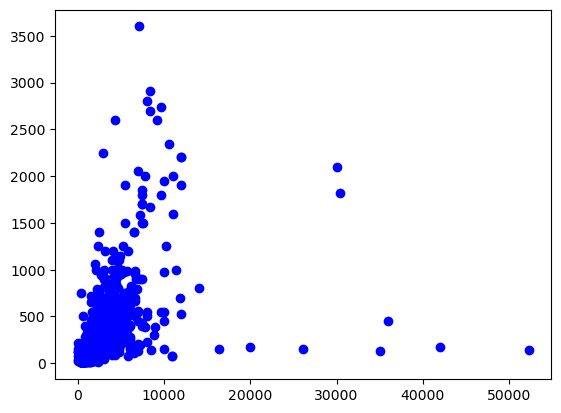

In [26]:
plt.scatter(X, y, color='blue' , label = 'Actual')


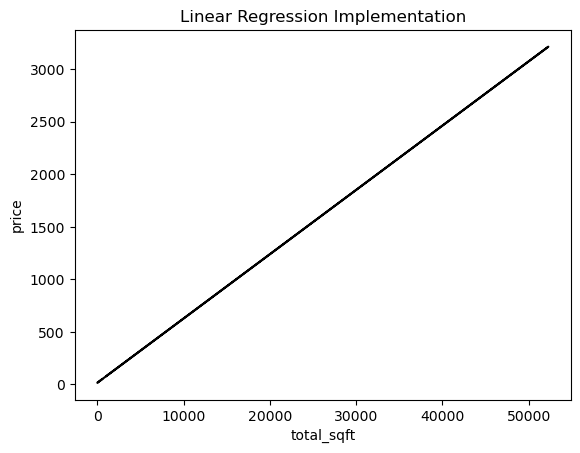

In [25]:
plt.plot(X, model.predict(X), color = 'Black', label = 'Predited')
plt.xlabel('total_sqft')
plt.ylabel('price')
plt.title('Linear Regression Implementation')
plt.show()